# Modèle Linéaire — Rosenblatt et Pseudo-Inverse
## Cas de tests, rendu 2

Ce notebook appelle directement les fonctions de `model_lineaire.c` via **ctypes** (librairie partagée `.so`).  
Fonctions C : `rosenblatt()` · `pseudo_inverse()` · `pseudo_inverse_reg()` · `gradient_descent()`

---

### Classification — Rosenblatt + Pseudo-Inverse (Tests 1 à 8)

| Test | Jeu de données | Attendu |
|------|----------------|---------|
| T1 | Linear Simple | **OK** — 100% les deux |
| T2 | Linear Multiple | **OK** — ~100% les deux |
| T3 | XOR brut | **KO** — ~50%, non séparable |
| T4 | XOR + φ(x₁,x₂) = [x₁,x₂,x₁·x₂,1] | **OK** — 100% les deux |
| T5 | Cross | **KO** — frontière non-linéaire |
| T6 | Multi Linear 3 classes | **OK** — ~100% les deux |
| T7 | Multi Cross 3 classes (damier) | **KO** — non séparable |
| **T8** | **dataset.csv — vraies images déchets (RGB)** | Résultat réel |

---

### Régression — Pseudo-Inverse + Gradient Descent (Tests R1 à R6)

| Test | Jeu de données | Attendu |
|------|----------------|---------|
| R1 | Linear Simple 2D | **OK** — droite exacte |
| R2 | Non Linear Simple 2D | **OK** — meilleure droite (moindres carrés) |
| R3 | Linear Simple 3D | **OK** — plan exact |
| R4 | Linear Tricky 3D (x₁=x₂ — singulier) | **OK** — ridge requis |
| R5 | Non Linear Simple 3D (inconsistant) | **KO** — modèle linéaire insuffisant |
| **R6** | **dataset.csv — vraies images déchets (label continu)** | Résultat réel |


## Imports


In [149]:
import subprocess, ctypes, sys, os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap
from pathlib import Path

warnings.filterwarnings('ignore', category=RuntimeWarning)

BASE     = Path("/Users/roissath/Documents/Cours 2025-2026/PA/projet_dechets")
C_FILE   = str(BASE / "model_lineaire/model_lineaire.c")
CSV_FILE = str(BASE / "dataset.csv")


## Étape 1 — Compilation de `model_lineaire.c` en librairie partagée

On compile le code C avec `-DNO_MAIN -shared -fPIC` pour créer un `.so` utilisable avec ctypes.


In [150]:
# Compilation dans /tmp pour ne pas polluer le projet
SO_FILE = f"/tmp/model_lineaire_{int(time.time())}.so"

for old in Path("/tmp").glob("model_lineaire_*.so"):
    try:
        old.unlink()
    except:
        pass

res = subprocess.run(
    ["gcc", "-shared", "-fPIC", "-DNO_MAIN", "-O2",
     "-o", SO_FILE, C_FILE, "-lm"],
    capture_output=True, text=True
)
if res.returncode != 0:
    print("Erreur de compilation :")
    print(res.stderr)
else:
    print("Compilation OK")

lib = ctypes.CDLL(SO_FILE)

lib.rosenblatt.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int, ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.rosenblatt.restype = None

lib.pseudo_inverse.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int, ctypes.c_int, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.pseudo_inverse.restype = None

lib.pseudo_inverse_reg.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double,
    ctypes.POINTER(ctypes.c_double),
]
lib.pseudo_inverse_reg.restype = None

lib.gradient_descent.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.gradient_descent.restype = None

print("Fonctions chargées : rosenblatt / pseudo_inverse / pseudo_inverse_reg / gradient_descent")


Compilation OK
Fonctions chargées : rosenblatt / pseudo_inverse / pseudo_inverse_reg / gradient_descent


## Étape 2 — Interface Python vers fonctions C

Buffers numpy de taille fixe (MAX_SAMP=1000, MAX_FEAT=5) passés via ctypes aux fonctions C.  
L'évaluation (accuracy, prédictions) est faite côté Python à partir des poids W retournés.


In [151]:
MAX_SAMP = 1000
MAX_FEAT = 5
MAX_CLS  = 3

# ── Style matplotlib (fond blanc, compatible thème sombre VS Code) ─────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor':'white',
})

def call_rosenblatt(X_np, Y_np, alpha=0.1, max_ep=500):
    n, nf = X_np.shape
    nc    = len(np.unique(Y_np))
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.int32)
    Y_c[:n] = Y_np.astype(np.int32)
    W_c = np.zeros((MAX_FEAT, MAX_CLS), dtype=np.float64, order='C')
    lib.rosenblatt(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
        ctypes.c_int(n), ctypes.c_int(nf), ctypes.c_int(nc),
        ctypes.c_double(alpha), ctypes.c_int(max_ep),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf, :nc].copy()

def call_pseudo_inverse(X_np, Y_np):
    n, nf = X_np.shape
    nc    = len(np.unique(Y_np))
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.int32)
    Y_c[:n] = Y_np.astype(np.int32)
    W_c = np.zeros((MAX_FEAT, MAX_CLS), dtype=np.float64, order='C')
    lib.pseudo_inverse(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
        ctypes.c_int(n), ctypes.c_int(nf), ctypes.c_int(nc),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf, :nc].copy()

def call_pseudo_inverse_reg(X_np, Y_reg, ridge=1e-8):
    n, nf = X_np.shape
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.float64)
    Y_c[:n] = Y_reg.astype(np.float64)
    W_c = np.zeros(MAX_FEAT, dtype=np.float64)
    lib.pseudo_inverse_reg(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.c_int(n), ctypes.c_int(nf),
        ctypes.c_double(ridge),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf].copy()

def call_gradient_descent(X_np, Y_reg, alpha=0.01, max_ep=1000):
    n, nf = X_np.shape
    X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order='C')
    X_c[:n, :nf] = X_np
    Y_c = np.zeros(MAX_SAMP, dtype=np.float64)
    Y_c[:n] = Y_reg.astype(np.float64)
    W_c = np.zeros(MAX_FEAT, dtype=np.float64)
    lib.gradient_descent(
        X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.c_int(n), ctypes.c_int(nf),
        ctypes.c_double(alpha), ctypes.c_int(max_ep),
        W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    )
    return W_c[:nf].copy()

def predict_py(W, X):
    return np.argmax(X @ W, axis=1)

def accuracy_py(W, X, Y):
    return np.mean(predict_py(W, X) == Y) * 100

def predict_reg_py(W, X):
    return X @ W

def mse_py(W, X, Y_reg):
    return np.mean((predict_reg_py(W, X) - Y_reg) ** 2)

def track_convergence_py(X, Y, alpha=0.1, max_ep=500):
    n, nf = X.shape
    nc = len(np.unique(Y))
    W  = np.zeros((nf, nc))
    errors = []
    for ep in range(max_ep):
        nb_err = 0
        for i in range(n):
            pred   = np.argmax(W.T @ X[i])
            true_c = int(Y[i])
            if pred != true_c:
                nb_err += 1
                W[:, true_c] += alpha * X[i]
                W[:, pred]   -= alpha * X[i]
        errors.append(nb_err)
        if nb_err == 0:
            break
    return errors

# ── Palette de couleurs vives (Material Design) ────────────────────────────────
COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']    # Bleu · Rouge · Vert · Orange
CMAP2  = ListedColormap(['#90CAF9', '#EF9A9A'])             # Bleu moyen / Rouge moyen  (2 cls)
CMAP3  = ListedColormap(['#90CAF9', '#EF9A9A', '#A5D6A7'])  # + Vert moyen              (3 cls)

_CLS_DEFAULT = {0: 'Classe 0', 1: 'Classe 1', 2: 'Classe 2', 3: 'Classe 3'}

def plot_boundary(ax, W, X_raw, Y, title, phi=None, nc=2, cls_names=None):
    """Frontière de décision avec marqueurs ● (bien classé) et ✗ (mal classé)."""
    names = cls_names if cls_names else _CLS_DEFAULT

    # ── Fond blanc explicite ──
    ax.set_facecolor('white')

    h = 0.04
    x_min, x_max = X_raw[:, 0].min() - 0.4, X_raw[:, 0].max() + 0.4
    y_min, y_max = X_raw[:, 1].min() - 0.4, X_raw[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid   = np.c_[xx.ravel(), yy.ravel()]
    grid_f = phi(grid) if phi else np.hstack([grid, np.ones((len(grid), 1))])
    Z = predict_py(W, grid_f).reshape(xx.shape)

    cmap = CMAP3 if nc == 3 else CMAP2
    # alpha=0.55 : bien visible sur fond blanc
    ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap,
                levels=np.arange(-0.5, nc + 0.5, 1))
    ax.contour(xx, yy, Z, colors='#455A64', linewidths=1.5, linestyles='--')

    # ── Prédictions sur les points d'entraînement ──
    X_f   = phi(X_raw) if phi else np.hstack([X_raw, np.ones((len(X_raw), 1))])
    preds = predict_py(W, X_f)

    for c in np.unique(Y).astype(int):
        m       = (Y == c)
        label   = names.get(c, f'Classe {c}')
        correct = m & (preds == c)
        wrong   = m & (preds != c)
        # ● Bien classés : cercle plein, contour blanc pour ressortir
        ax.scatter(X_raw[correct, 0], X_raw[correct, 1],
                   color=COLORS[c], s=80, edgecolors='white', linewidths=0.8,
                   zorder=5, label=f'{label} ●')
        # ✗ Mal classés : croix noire encadrée (même couleur de classe)
        if np.any(wrong):
            ax.scatter(X_raw[wrong, 0], X_raw[wrong, 1],
                       color=COLORS[c], s=180, marker='X',
                       edgecolors='black', linewidths=1.0,
                       zorder=6, label=f'{label} ✗')

    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.25, color='gray')

print("Helpers prêts ✓")
print(f"COLORS = {COLORS}")


Helpers prêts ✓
COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']


## Classification


### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK


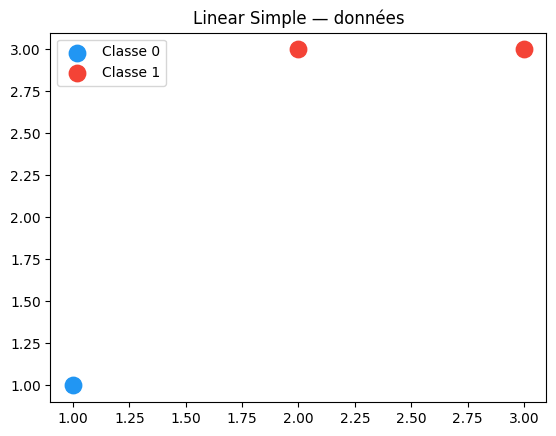

In [152]:
X1_raw = np.array([[1, 1], [2, 3], [3, 3]], dtype=float)
Y1     = np.array([0, 1, 1])

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')
ax.scatter(X1_raw[0:1, 0], X1_raw[0:1, 1], color=COLORS[0], s=140, label='Classe 0')
ax.scatter(X1_raw[1:3, 0], X1_raw[1:3, 1], color=COLORS[1], s=140, label='Classe 1')
ax.legend(); ax.set_title("Linear Simple — données")
plt.show()


Rosenblatt  : 100%  (attendu 100%)
Pseudo-Inv  : 100%  (attendu 100%)


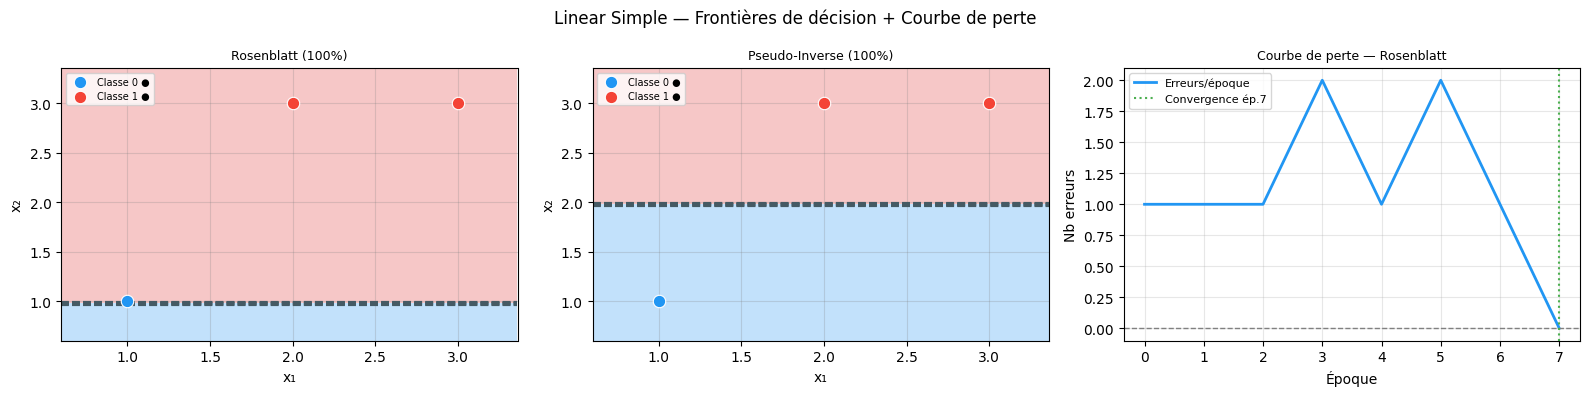

In [179]:
X1 = np.hstack([X1_raw, np.ones((len(X1_raw), 1))])

W1_r = call_rosenblatt(X1, Y1, alpha=0.1, max_ep=500)
W1_p = call_pseudo_inverse(X1, Y1)

acc1_r = accuracy_py(W1_r, X1, Y1)
acc1_p = accuracy_py(W1_p, X1, Y1)

print(f"Rosenblatt  : {acc1_r:.0f}%  (attendu 100%)")
print(f"Pseudo-Inv  : {acc1_p:.0f}%  (attendu 100%)")

errors1_r = track_convergence_py(X1, Y1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Linear Simple — Frontières de décision + Courbe de perte", fontsize=12)
plot_boundary(axes[0], W1_r, X1_raw, Y1, f"Rosenblatt ({acc1_r:.0f}%)")
plot_boundary(axes[1], W1_p, X1_raw, Y1, f"Pseudo-Inverse ({acc1_p:.0f}%)")

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors1_r, color=COLORS[0], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
if min(errors1_r) == 0:
    ep = errors1_r.index(0)
    ax.axvline(ep, color='#4CAF50', ls=':', lw=1.5, label=f"Convergence ép.{ep}")
ax.set_title("Courbe de perte — Rosenblatt", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK


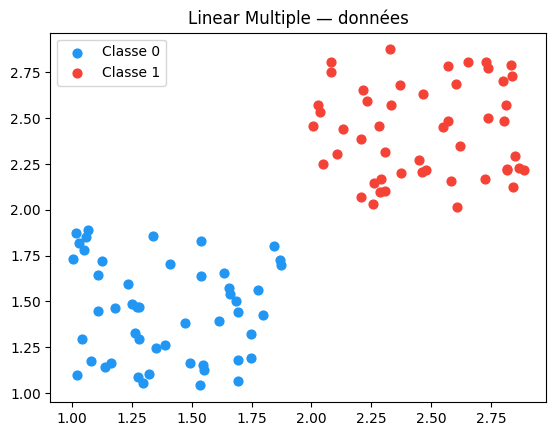

In [154]:
np.random.seed(42)
X2_raw = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2])
])
Y2 = np.concatenate([np.zeros(50, dtype=int), np.ones(50, dtype=int)])

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')
ax.scatter(X2_raw[0:50, 0],   X2_raw[0:50, 1],   color=COLORS[0], s=40, label='Classe 0')
ax.scatter(X2_raw[50:100, 0], X2_raw[50:100, 1], color=COLORS[1], s=40, label='Classe 1')
ax.legend(); ax.set_title("Linear Multiple — données")
plt.show()


Rosenblatt  : 100%  (attendu ~100%)
Pseudo-Inv  : 100%  (attendu ~100%)


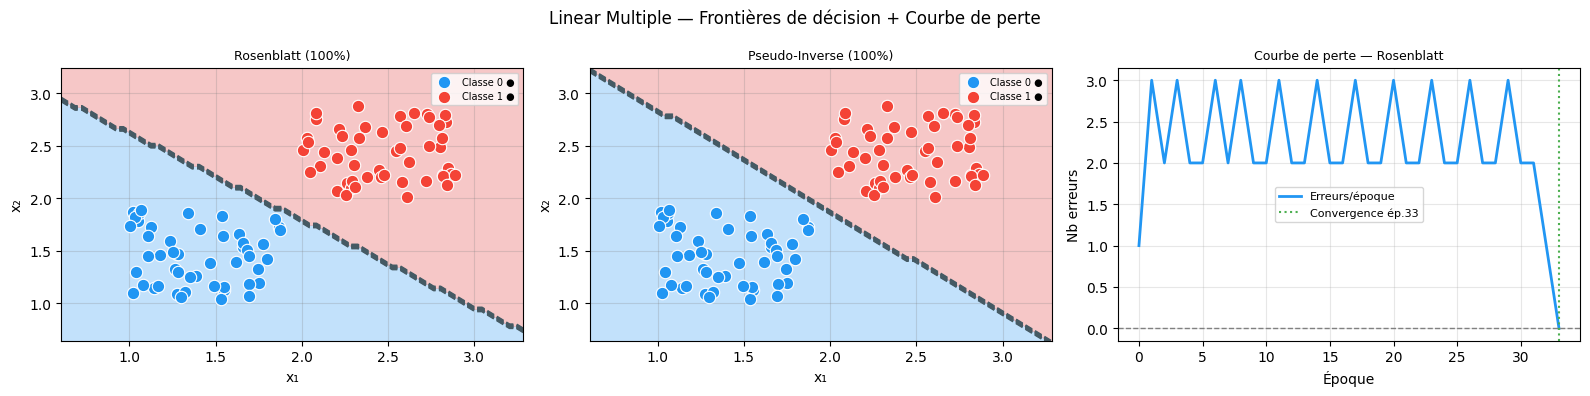

In [155]:
X2 = np.hstack([X2_raw, np.ones((100, 1))])

W2_r = call_rosenblatt(X2, Y2, alpha=0.1, max_ep=500)
W2_p = call_pseudo_inverse(X2, Y2)

acc2_r = accuracy_py(W2_r, X2, Y2)
acc2_p = accuracy_py(W2_p, X2, Y2)

print(f"Rosenblatt  : {acc2_r:.0f}%  (attendu ~100%)")
print(f"Pseudo-Inv  : {acc2_p:.0f}%  (attendu ~100%)")

errors2_r = track_convergence_py(X2, Y2, alpha=0.1, max_ep=500)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Linear Multiple — Frontières de décision + Courbe de perte", fontsize=12)
plot_boundary(axes[0], W2_r, X2_raw, Y2, f"Rosenblatt ({acc2_r:.0f}%)")
plot_boundary(axes[1], W2_p, X2_raw, Y2, f"Pseudo-Inverse ({acc2_p:.0f}%)")

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors2_r, color=COLORS[0], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
if min(errors2_r) == 0:
    ep = errors2_r.index(0)
    ax.axvline(ep, color='#4CAF50', ls=':', lw=1.5, label=f"Convergence ép.{ep}")
ax.set_title("Courbe de perte — Rosenblatt", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : KO aussi (modèle linéaire ne peut pas résoudre XOR)


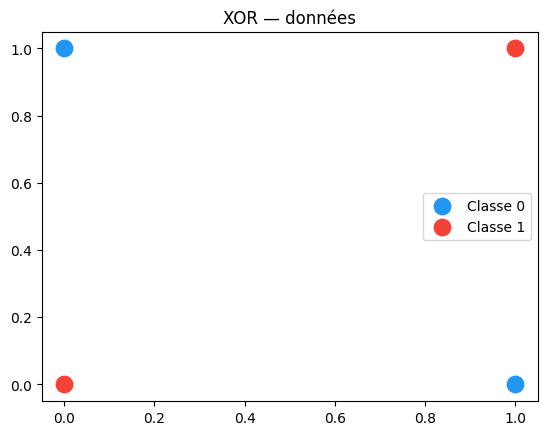

In [156]:
X3_raw = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=float)
Y3     = np.array([0, 0, 1, 1])

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')
ax.scatter(X3_raw[0:2, 0], X3_raw[0:2, 1], color=COLORS[0], s=140, label='Classe 0')
ax.scatter(X3_raw[2:4, 0], X3_raw[2:4, 1], color=COLORS[1], s=140, label='Classe 1')
ax.legend(); ax.set_title("XOR — données")
plt.show()


Rosenblatt  : 50%  (attendu ~50% — KO non séparable)
Pseudo-Inv  : 50%  (attendu ~50% — KO)

  idx | vrai | Rosenblatt | Pseudo-Inv
  ----|------|------------|----------
   0  |  0   |  1 KO      |  0 OK
   1  |  0   |  1 KO      |  0 OK
   2  |  1   |  1 OK      |  0 KO
   3  |  1   |  1 OK      |  0 KO


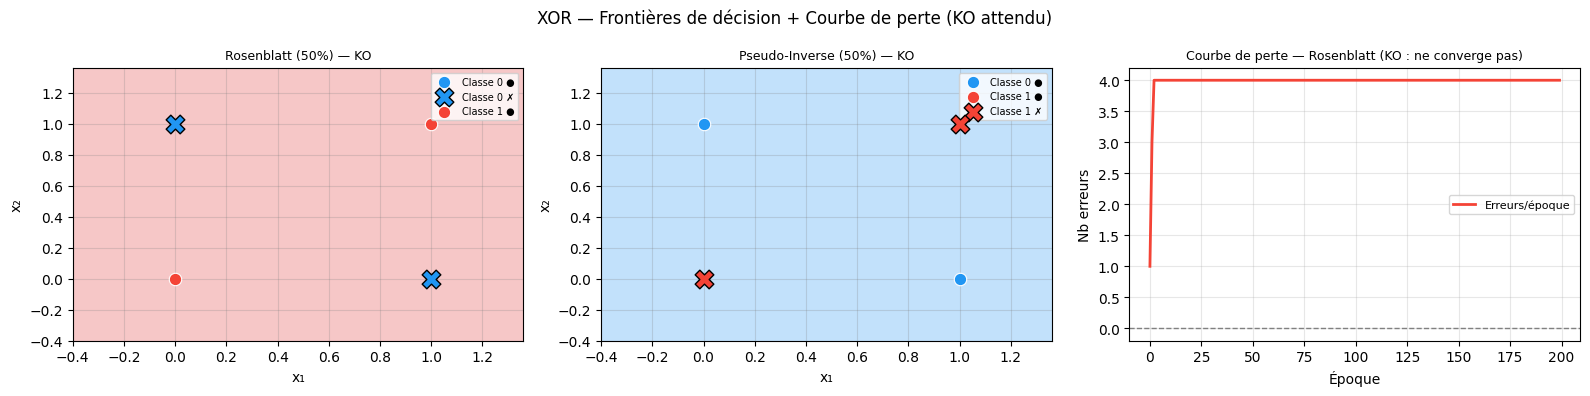

In [157]:
X3 = np.hstack([X3_raw, np.ones((len(X3_raw), 1))])

W3_r = call_rosenblatt(X3, Y3, alpha=0.1, max_ep=200)
W3_p = call_pseudo_inverse(X3, Y3)

acc3_r = accuracy_py(W3_r, X3, Y3)
acc3_p = accuracy_py(W3_p, X3, Y3)

print(f"Rosenblatt  : {acc3_r:.0f}%  (attendu ~50% — KO non séparable)")
print(f"Pseudo-Inv  : {acc3_p:.0f}%  (attendu ~50% — KO)")

preds3_r = predict_py(W3_r, X3)
preds3_p = predict_py(W3_p, X3)
print("\n  idx | vrai | Rosenblatt | Pseudo-Inv")
print("  ----|------|------------|----------")
for i in range(len(Y3)):
    ok_r = "OK" if preds3_r[i]==Y3[i] else "KO"
    ok_p = "OK" if preds3_p[i]==Y3[i] else "KO"
    print(f"   {i}  |  {int(Y3[i])}   |  {preds3_r[i]} {ok_r}      |  {preds3_p[i]} {ok_p}")

errors3_r = track_convergence_py(X3, Y3, max_ep=200)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("XOR — Frontières de décision + Courbe de perte (KO attendu)", fontsize=12)
plot_boundary(axes[0], W3_r, X3_raw, Y3, f"Rosenblatt ({acc3_r:.0f}%) — KO")
plot_boundary(axes[1], W3_p, X3_raw, Y3, f"Pseudo-Inverse ({acc3_p:.0f}%) — KO")

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors3_r, color=COLORS[1], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title("Courbe de perte — Rosenblatt (KO : ne converge pas)", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### XOR + φ(x₁,x₂) :
$$\phi(x_1, x_2) = [x_1,\ x_2,\ x_1 \cdot x_2,\ 1]$$

La feature $x_1 \cdot x_2$ rend le problème **linéairement séparable**.  
        Linear Model (avec phi) : OK


Rosenblatt  : 100%  (attendu 100% — OK avec phi)
Pseudo-Inv  : 100%  (attendu 100%)


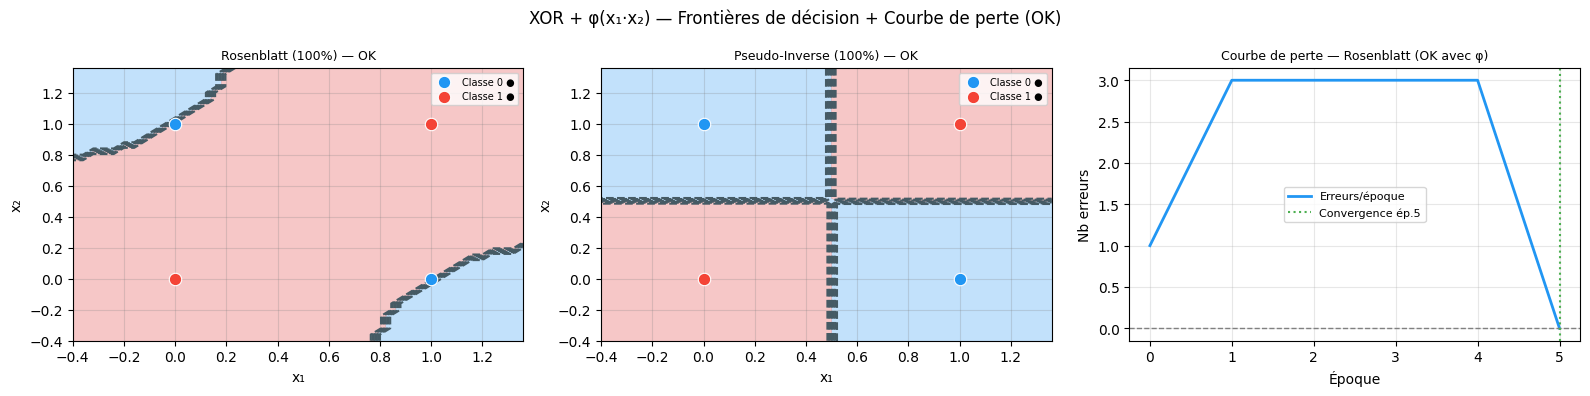

In [158]:
def phi_xor(raw):
    x1, x2 = raw[:, 0], raw[:, 1]
    return np.column_stack([x1, x2, x1 * x2, np.ones(len(raw))])

X4_phi = phi_xor(X3_raw)  # nf=4
Y4     = np.array([0, 0, 1, 1])

W4_r = call_rosenblatt(X4_phi, Y4, alpha=0.1, max_ep=500)
W4_p = call_pseudo_inverse(X4_phi, Y4)

acc4_r = accuracy_py(W4_r, X4_phi, Y4)
acc4_p = accuracy_py(W4_p, X4_phi, Y4)

print(f"Rosenblatt  : {acc4_r:.0f}%  (attendu 100% — OK avec phi)")
print(f"Pseudo-Inv  : {acc4_p:.0f}%  (attendu 100%)")

errors4_r = track_convergence_py(X4_phi, Y4)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("XOR + φ(x₁·x₂) — Frontières de décision + Courbe de perte (OK)", fontsize=12)
plot_boundary(axes[0], W4_r, X3_raw, Y4, f"Rosenblatt ({acc4_r:.0f}%) — OK", phi=phi_xor)
plot_boundary(axes[1], W4_p, X3_raw, Y4, f"Pseudo-Inverse ({acc4_p:.0f}%) — OK", phi=phi_xor)

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors4_r, color=COLORS[0], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
if min(errors4_r) == 0:
    ep = errors4_r.index(0)
    ax.axvline(ep, color='#4CAF50', ls=':', lw=1.5, label=f"Convergence ép.{ep}")
ax.set_title("Courbe de perte — Rosenblatt (OK avec φ)", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : KO aussi (modèle linéaire uniquement)


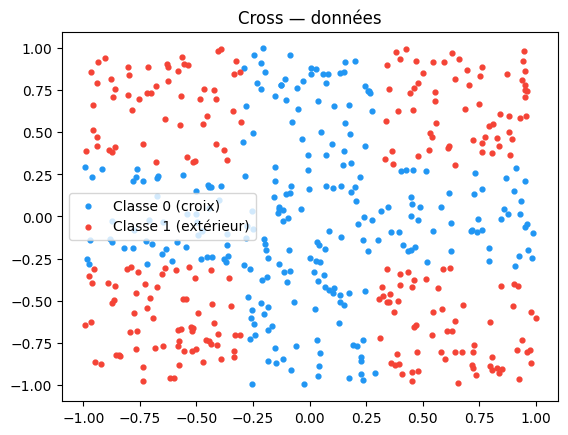

In [159]:
np.random.seed(0)
X5_raw = np.random.random((500, 2)) * 2.0 - 1.0
Y5 = np.array([0 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else 1 for p in X5_raw], dtype=int)

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')
ax.scatter(X5_raw[Y5==0, 0], X5_raw[Y5==0, 1], color=COLORS[0], s=12, label='Classe 0 (croix)')
ax.scatter(X5_raw[Y5==1, 0], X5_raw[Y5==1, 1], color=COLORS[1], s=12, label='Classe 1 (extérieur)')
ax.legend(); ax.set_title("Cross — données")
plt.show()


Rosenblatt  : 45%  (KO — non linéairement séparable)
Pseudo-Inv  : 50%  (KO)


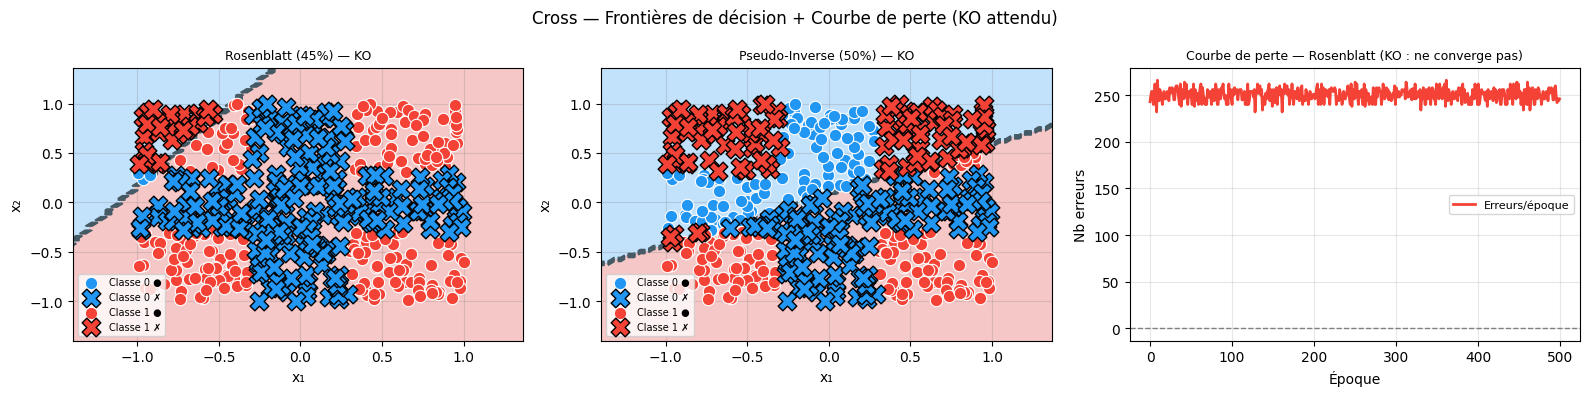

In [160]:
X5 = np.hstack([X5_raw, np.ones((len(X5_raw), 1))])

W5_r = call_rosenblatt(X5, Y5, alpha=0.01, max_ep=500)
W5_p = call_pseudo_inverse(X5, Y5)

acc5_r = accuracy_py(W5_r, X5, Y5)
acc5_p = accuracy_py(W5_p, X5, Y5)

print(f"Rosenblatt  : {acc5_r:.0f}%  (KO — non linéairement séparable)")
print(f"Pseudo-Inv  : {acc5_p:.0f}%  (KO)")

errors5_r = track_convergence_py(X5, Y5, alpha=0.01, max_ep=500)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Cross — Frontières de décision + Courbe de perte (KO attendu)", fontsize=12)
plot_boundary(axes[0], W5_r, X5_raw, Y5, f"Rosenblatt ({acc5_r:.0f}%) — KO")
plot_boundary(axes[1], W5_p, X5_raw, Y5, f"Pseudo-Inverse ({acc5_p:.0f}%) — KO")

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors5_r, color=COLORS[1], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title("Courbe de perte — Rosenblatt (KO : ne converge pas)", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK


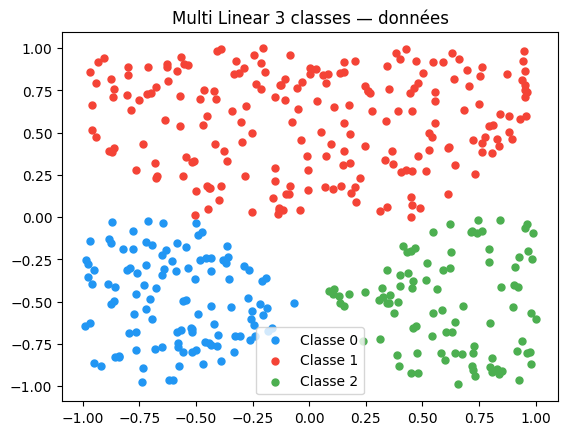

In [161]:
np.random.seed(0)
X6_all = np.random.random((500, 2)) * 2.0 - 1.0
labels6 = np.array([
    0 if (-p[0]-p[1]-0.5 > 0 and p[1] < 0 and p[0]-p[1]-0.5 < 0) else
    1 if (-p[0]-p[1]-0.5 < 0 and p[1] > 0 and p[0]-p[1]-0.5 < 0) else
    2 if (-p[0]-p[1]-0.5 < 0 and p[1] < 0 and p[0]-p[1]-0.5 > 0) else
    -1
    for p in X6_all])
mask6 = labels6 >= 0
X6_raw = X6_all[mask6]
Y6 = labels6[mask6].astype(int)

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')
ax.scatter(X6_raw[Y6==0, 0], X6_raw[Y6==0, 1], color=COLORS[0], s=25, label='Classe 0')
ax.scatter(X6_raw[Y6==1, 0], X6_raw[Y6==1, 1], color=COLORS[1], s=25, label='Classe 1')
ax.scatter(X6_raw[Y6==2, 0], X6_raw[Y6==2, 1], color=COLORS[2], s=25, label='Classe 2')
ax.legend(); ax.set_title("Multi Linear 3 classes — données")
plt.show()


Rosenblatt  : 100%  (attendu ~100%)
Pseudo-Inv  : 100%  (attendu ~100%)


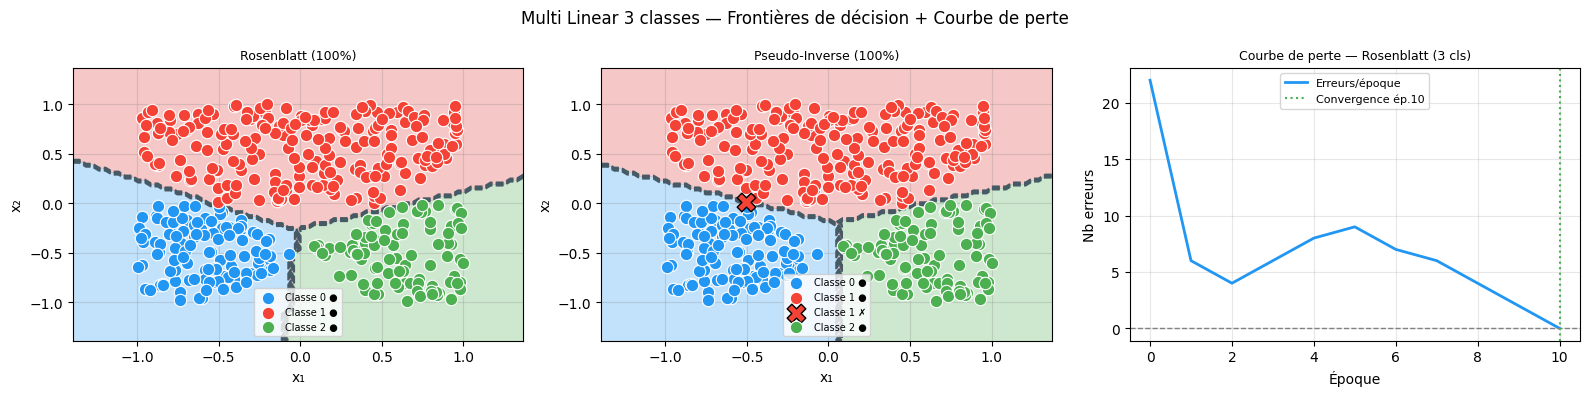

In [162]:
X6 = np.hstack([X6_raw, np.ones((len(X6_raw), 1))])

W6_r = call_rosenblatt(X6, Y6, alpha=0.1, max_ep=1000)
W6_p = call_pseudo_inverse(X6, Y6)

acc6_r = accuracy_py(W6_r, X6, Y6)
acc6_p = accuracy_py(W6_p, X6, Y6)

print(f"Rosenblatt  : {acc6_r:.0f}%  (attendu ~100%)")
print(f"Pseudo-Inv  : {acc6_p:.0f}%  (attendu ~100%)")

errors6_r = track_convergence_py(X6, Y6, alpha=0.1, max_ep=1000)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Multi Linear 3 classes — Frontières de décision + Courbe de perte", fontsize=12)
plot_boundary(axes[0], W6_r, X6_raw, Y6, f"Rosenblatt ({acc6_r:.0f}%)", nc=3)
plot_boundary(axes[1], W6_p, X6_raw, Y6, f"Pseudo-Inverse ({acc6_p:.0f}%)", nc=3)

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors6_r, color=COLORS[0], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
if min(errors6_r) == 0:
    ep = errors6_r.index(0)
    ax.axvline(ep, color='#4CAF50', ls=':', lw=1.5, label=f"Convergence ép.{ep}")
ax.set_title("Courbe de perte — Rosenblatt (3 cls)", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Multi Cross 3 classes :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): KO aussi (modèle linéaire uniquement)


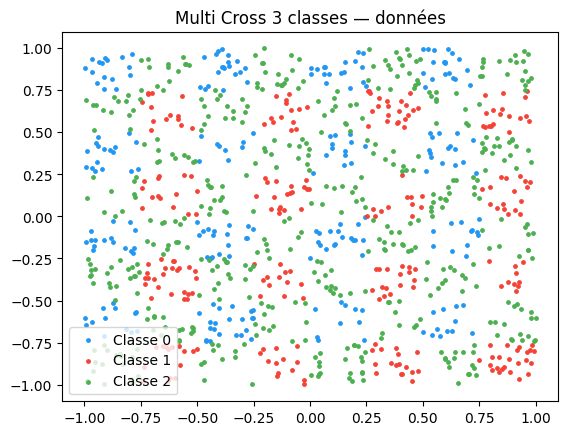

In [163]:
np.random.seed(0)
X7_raw = np.random.random((1000, 2)) * 2.0 - 1.0
Y7 = np.array([
    0 if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else
    1 if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else
    2
    for p in X7_raw], dtype=int)

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')
ax.scatter(X7_raw[Y7==0, 0], X7_raw[Y7==0, 1], color=COLORS[0], s=6, label='Classe 0')
ax.scatter(X7_raw[Y7==1, 0], X7_raw[Y7==1, 1], color=COLORS[1], s=6, label='Classe 1')
ax.scatter(X7_raw[Y7==2, 0], X7_raw[Y7==2, 1], color=COLORS[2], s=6, label='Classe 2')
ax.legend(); ax.set_title("Multi Cross 3 classes — données")
plt.show()


Rosenblatt  : 30%  (KO — non séparable)
Pseudo-Inv  : 49%  (KO)


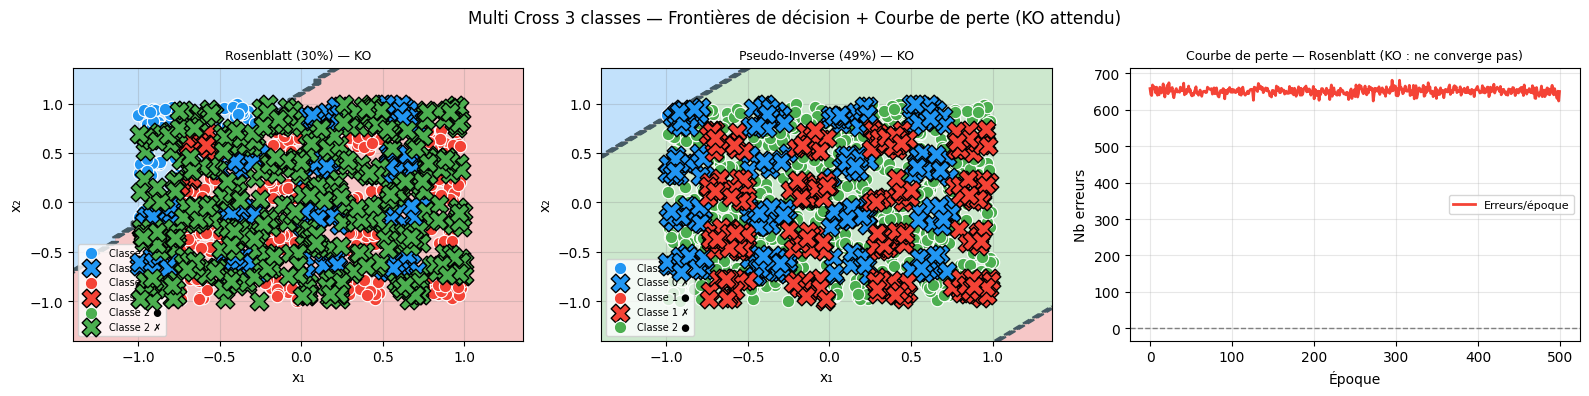

In [164]:
X7 = np.hstack([X7_raw, np.ones((len(X7_raw), 1))])

W7_r = call_rosenblatt(X7, Y7, alpha=0.01, max_ep=500)
W7_p = call_pseudo_inverse(X7, Y7)

acc7_r = accuracy_py(W7_r, X7, Y7)
acc7_p = accuracy_py(W7_p, X7, Y7)

print(f"Rosenblatt  : {acc7_r:.0f}%  (KO — non séparable)")
print(f"Pseudo-Inv  : {acc7_p:.0f}%  (KO)")

errors7_r = track_convergence_py(X7, Y7, alpha=0.01, max_ep=500)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Multi Cross 3 classes — Frontières de décision + Courbe de perte (KO attendu)", fontsize=12)
plot_boundary(axes[0], W7_r, X7_raw, Y7, f"Rosenblatt ({acc7_r:.0f}%) — KO", nc=3)
plot_boundary(axes[1], W7_p, X7_raw, Y7, f"Pseudo-Inverse ({acc7_p:.0f}%) — KO", nc=3)

ax = axes[2]; ax.set_facecolor('white')
ax.plot(errors7_r, color=COLORS[1], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title("Courbe de perte — Rosenblatt (KO : ne converge pas)", fontsize=9)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Test 8 — Dataset réel : 3 classes (Compost · Pile · Recyclable)

On passe le **vrai dataset CSV** aux fonctions C :  
- n ≈ 58 échantillons · nf = 4 (R, G, B normalisés + biais) · **nc = 3 classes**

> Classes : **0 = Compost · 1 = Pile · 2 = Recyclable**


In [165]:
# Chargement du dataset
df = pd.read_csv(CSV_FILE)
print(f"Dataset : {len(df)} lignes × {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")
print()
print(df.head())
print()
print("Distribution des classes :")
print(df['label'].value_counts().sort_index())

# Labels déjà entiers : 0=Compost, 1=Pile, 2=Recyclable
label_map  = {0: "Compost", 1: "Pile", 2: "Recyclable"}
cls_names  = [label_map[i] for i in sorted(label_map)]

X_raw  = df[['r_mean', 'g_mean', 'b_mean']].values.astype(np.float64)
Y_real = df['label'].values.astype(np.int32)

# Normalisation min-max
X_min  = X_raw.min(axis=0)
X_max  = X_raw.max(axis=0)
X_norm = (X_raw - X_min) / (X_max - X_min + 1e-8)

# Ajout du biais
X_real = np.hstack([X_norm, np.ones((len(X_norm), 1))])

print(f"\nX_real shape : {X_real.shape}  (n={len(X_real)}, nf={X_real.shape[1]})")
print(f"Classes : {np.unique(Y_real)}  →  {len(np.unique(Y_real))} classes")
print("Dataset prêt")


Dataset : 57 lignes × 4 colonnes
Colonnes : ['r_mean', 'g_mean', 'b_mean', 'label']

       r_mean      g_mean      b_mean  label
0  196.843810  206.318599  193.278380      2
1  208.687679  191.076092  182.135802      0
2  200.695193  183.621114  167.739377      0
3  176.875060  160.385144  147.585320      0
4  165.085798  114.279357   76.572943      0

Distribution des classes :
label
0    24
1    11
2    22
Name: count, dtype: int64

X_real shape : (57, 4)  (n=57, nf=4)
Classes : [0 1 2]  →  3 classes
Dataset prêt


In [166]:
# alpha=0.1 + max_ep=3000 : bien meilleur qu'alpha=0.01/1000 pour données réelles 3 classes
W8_r = call_rosenblatt(X_real, Y_real, alpha=0.1, max_ep=3000)
W8_p = call_pseudo_inverse(X_real, Y_real)

acc8_r = accuracy_py(W8_r, X_real, Y_real)
acc8_p = accuracy_py(W8_p, X_real, Y_real)

preds8_r = predict_py(W8_r, X_real)
preds8_p = predict_py(W8_p, X_real)

print(f"Rosenblatt  (α=0.1, ep=3000) : {acc8_r:.1f}%")
print(f"Pseudo-Inv  (analytique)     : {acc8_p:.1f}%")
print()
print(f"  {'Classe':12s}  | Rosenblatt       | Pseudo-Inverse")
print(f"  {'-'*12}--+------------------+---------------")
for cls_idx, cls_name in label_map.items():
    mask  = Y_real == cls_idx
    ok_r  = np.sum(preds8_r[mask] == cls_idx)
    ok_p  = np.sum(preds8_p[mask] == cls_idx)
    total = np.sum(mask)
    print(f"  {cls_name:12s}  |  {ok_r}/{total} ({100*ok_r/total:5.1f}%)   |  {ok_p}/{total} ({100*ok_p/total:5.1f}%)")

errors8_r = track_convergence_py(X_real, Y_real, alpha=0.1, max_ep=3000)

# Courbe de perte Rosenblatt sur dataset réel
fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')
ax.set_facecolor('white')
ax.plot(errors8_r, color=COLORS[3], lw=2, label='Erreurs/époque')
ax.axhline(0, color='gray', ls='--', lw=1)
if min(errors8_r) == 0:
    ep = errors8_r.index(0)
    ax.axvline(ep, color='#4CAF50', ls=':', lw=1.5, label=f"Convergence ép.{ep}")
ax.set_title("T8 — Courbe de perte Rosenblatt (Dataset réel RGB, 3 classes)", fontsize=10)
ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Rosenblatt  (α=0.1, ep=3000) : 43.9%
Pseudo-Inv  (analytique)     : 66.7%

  Classe        | Rosenblatt       | Pseudo-Inverse
  --------------+------------------+---------------
  Compost       |  0/24 (  0.0%)   |  20/24 ( 83.3%)
  Pile          |  3/11 ( 27.3%)   |  0/11 (  0.0%)
  Recyclable    |  22/22 (100.0%)   |  18/22 ( 81.8%)


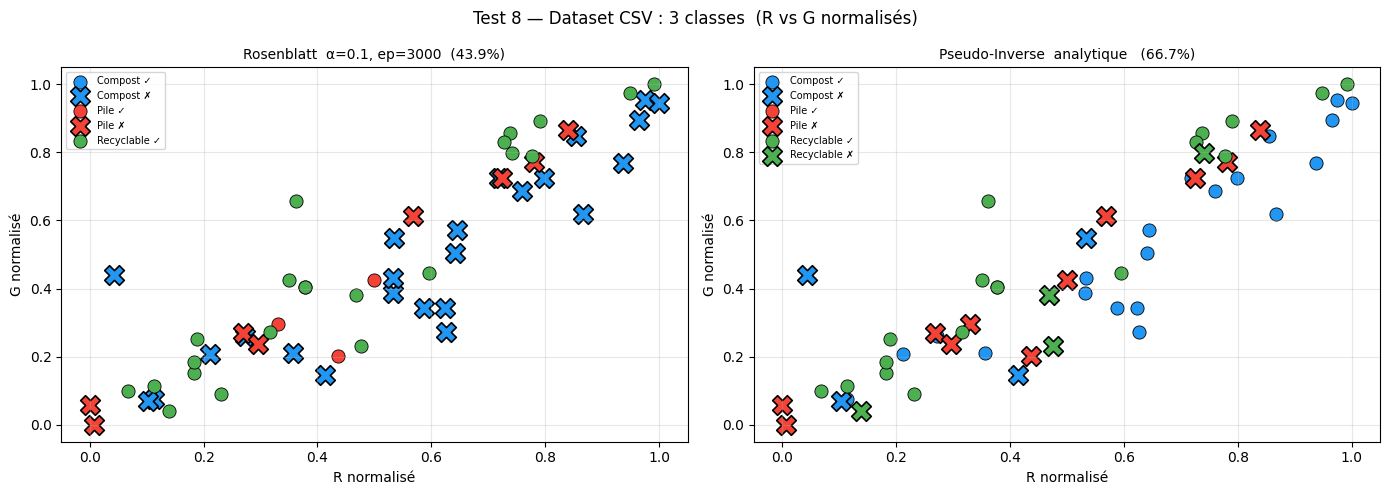

In [167]:
# Scatter R vs G normalisés — ✓ bien classé · ✗ mal classé (même couleur de classe, forme X)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test 8 — Dataset CSV : 3 classes  (R vs G normalisés)", fontsize=12)

for ax, (W_plot, title, preds) in zip(axes, [
    (W8_r, f"Rosenblatt  α=0.1, ep=3000  ({acc8_r:.1f}%)", preds8_r),
    (W8_p, f"Pseudo-Inverse  analytique   ({acc8_p:.1f}%)", preds8_p),
]):
    for c, name in label_map.items():
        mask    = Y_real == c
        correct = preds == c
        # Points bien classés : disque plein
        ax.scatter(X_real[mask & correct,  0], X_real[mask & correct,  1],
                   color=COLORS[c], s=90, edgecolors='k', lw=0.6,
                   label=f'{name} ✓')
        # Points mal classés : croix (même couleur de classe pour traçabilité)
        if np.any(mask & ~correct):
            ax.scatter(X_real[mask & ~correct, 0], X_real[mask & ~correct, 1],
                       color=COLORS[c], s=200, marker='X', edgecolors='k', lw=1.2,
                       label=f'{name} ✗')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("R normalisé"); ax.set_ylabel("G normalisé")
    ax.legend(fontsize=7, loc='best'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Régression
Pseudo-inverse analytique (`pseudo_inverse_reg`) et descente de gradient (`gradient_descent`).

| # | Données | n | nf | Attendu |
|---|---------|---|----|---------|
| R1 | Linear Simple 2D | 2 | 2 | OK |
| R2 | Non Linear Simple 2D | 3 | 2 | OK (meilleure droite) |
| R3 | Linear Simple 3D | 3 | 3 | OK |
| R4 | Linear Tricky 3D (x₁=x₂) | 3 | 3 | OK (ridge) |
| R5 | Non Linear Simple 3D | 4 | 3 | KO |
| **R6** | **Dataset réel RGB — label continu (0/1/2)** | ≈58 | 4 | Résultat réel |


### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK


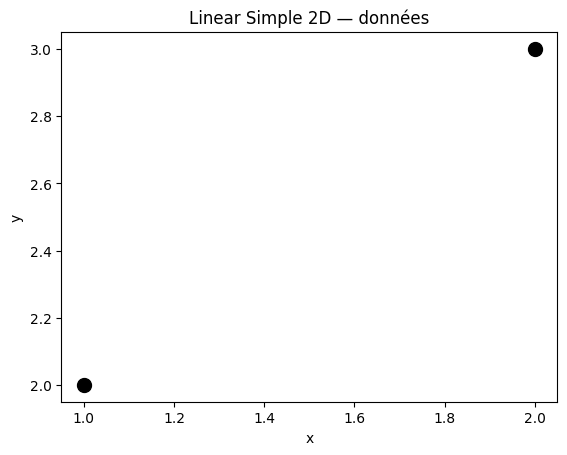

<Figure size 640x480 with 0 Axes>

In [168]:
X_r1 = np.array([[1, 1], [2, 1]], dtype=float)
Y_r1 = np.array([2.0, 3.0])

plt.scatter(X_r1[:, 0], Y_r1, color='k', s=100, zorder=5)
plt.title("Linear Simple 2D — données"); plt.xlabel("x"); plt.ylabel("y")
plt.show(); plt.clf()


R1 — Linear Simple 2D :
  Pseudo-Inv : W=[1. 1.]  MSE=5.00e-17  (OK)
  Grad Desc  : W=[1. 1.]  MSE=7.68e-11  (OK)


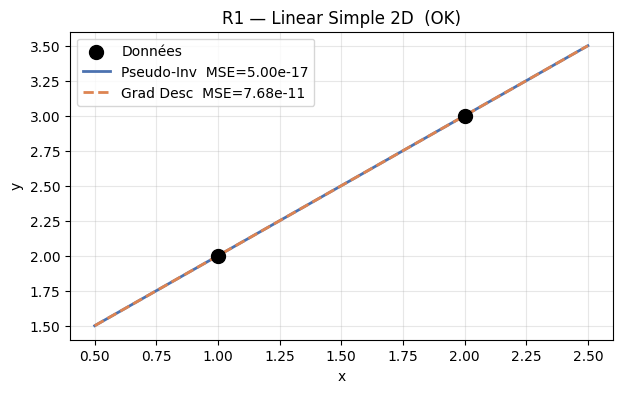

In [169]:
W_r1_pi = call_pseudo_inverse_reg(X_r1, Y_r1)
W_r1_gd = call_gradient_descent(X_r1, Y_r1, alpha=0.1, max_ep=2000)

print("R1 — Linear Simple 2D :")
print(f"  Pseudo-Inv : W={np.round(W_r1_pi,4)}  MSE={mse_py(W_r1_pi,X_r1,Y_r1):.2e}  (OK)")
print(f"  Grad Desc  : W={np.round(W_r1_gd,4)}  MSE={mse_py(W_r1_gd,X_r1,Y_r1):.2e}  (OK)")

x_plot = np.linspace(0.5, 2.5, 50)
X_line = np.column_stack([x_plot, np.ones(50)])

plt.figure(figsize=(7, 4))
plt.scatter(X_r1[:,0], Y_r1, color='k', s=100, zorder=5, label='Données')
plt.plot(x_plot, X_line @ W_r1_pi, color='#4C72B0', lw=2, label=f'Pseudo-Inv  MSE={mse_py(W_r1_pi,X_r1,Y_r1):.2e}')
plt.plot(x_plot, X_line @ W_r1_gd, color='#DD8452', lw=2, ls='--', label=f'Grad Desc  MSE={mse_py(W_r1_gd,X_r1,Y_r1):.2e}')
plt.title("R1 — Linear Simple 2D  (OK)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


### Non Linear Simple 2D :
        Linear Model    : OK (meilleure droite, moindres carrés)
        MLP (1, ?, 1)   : OK


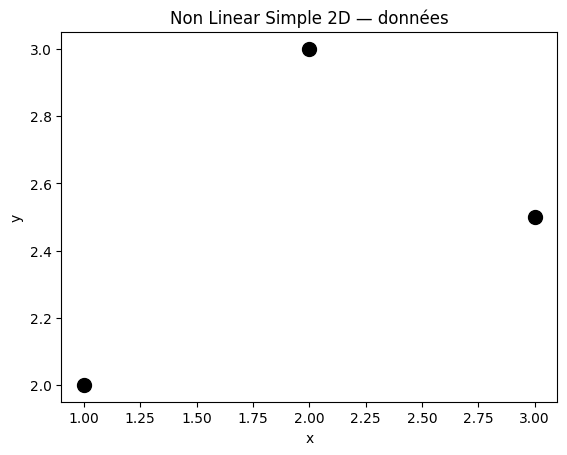

R2 — Non Linear Simple 2D :
  Pseudo-Inv : W=[0.25 2.  ]  MSE=0.1250  (OK — meilleure droite)
  Grad Desc  : W=[0.1779 2.1106]  MSE=0.1296  (OK)


<Figure size 640x480 with 0 Axes>

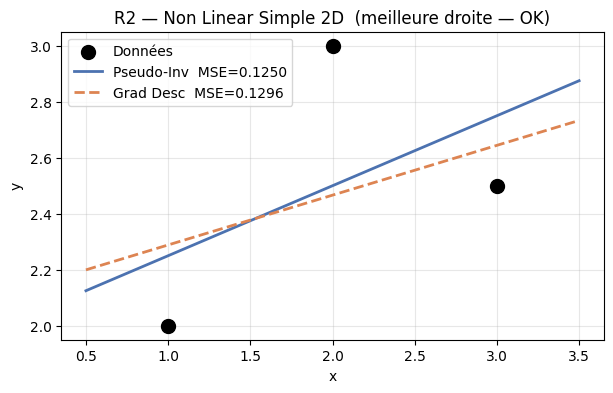

In [170]:
X_r2 = np.array([[1, 1], [2, 1], [3, 1]], dtype=float)
Y_r2 = np.array([2.0, 3.0, 2.5])

plt.scatter(X_r2[:, 0], Y_r2, color='k', s=100, zorder=5)
plt.title("Non Linear Simple 2D — données"); plt.xlabel("x"); plt.ylabel("y")
plt.show(); plt.clf()

W_r2_pi = call_pseudo_inverse_reg(X_r2, Y_r2)
W_r2_gd = call_gradient_descent(X_r2, Y_r2, alpha=0.05, max_ep=5000)

print("R2 — Non Linear Simple 2D :")
print(f"  Pseudo-Inv : W={np.round(W_r2_pi,4)}  MSE={mse_py(W_r2_pi,X_r2,Y_r2):.4f}  (OK — meilleure droite)")
print(f"  Grad Desc  : W={np.round(W_r2_gd,4)}  MSE={mse_py(W_r2_gd,X_r2,Y_r2):.4f}  (OK)")

x_plot2 = np.linspace(0.5, 3.5, 50)
X_line2 = np.column_stack([x_plot2, np.ones(50)])

plt.figure(figsize=(7, 4))
plt.scatter(X_r2[:,0], Y_r2, color='k', s=100, zorder=5, label='Données')
plt.plot(x_plot2, X_line2 @ W_r2_pi, color='#4C72B0', lw=2, label=f'Pseudo-Inv  MSE={mse_py(W_r2_pi,X_r2,Y_r2):.4f}')
plt.plot(x_plot2, X_line2 @ W_r2_gd, color='#DD8452', lw=2, ls='--', label=f'Grad Desc  MSE={mse_py(W_r2_gd,X_r2,Y_r2):.4f}')
plt.title("R2 — Non Linear Simple 2D  (meilleure droite — OK)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK


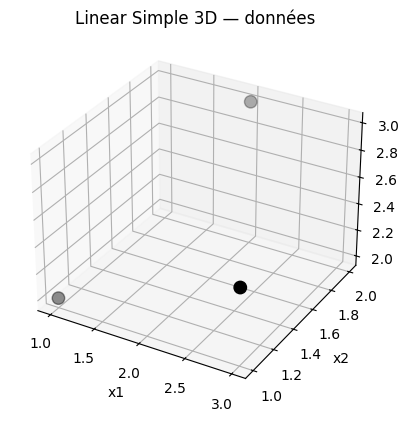

R3 — Linear Simple 3D :
  Pseudo-Inv : W=[0.25 0.75 1.  ]  MSE=7.92e-17  (OK)
  Grad Desc  : W=[0.25 0.75 1.  ]  MSE=8.02e-11  (OK)


<Figure size 640x480 with 0 Axes>

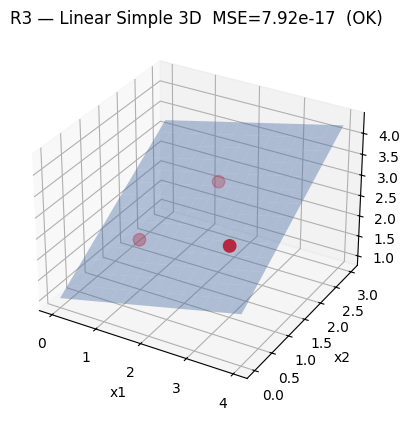

In [171]:
from mpl_toolkits.mplot3d import Axes3D

X_r3 = np.array([[1, 1, 1], [2, 2, 1], [3, 1, 1]], dtype=float)
Y_r3 = np.array([2.0, 3.0, 2.5])

fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_r3[:,0], X_r3[:,1], Y_r3, color='k', s=80)
ax.set_title("Linear Simple 3D — données"); ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
plt.show(); plt.clf()

W_r3_pi = call_pseudo_inverse_reg(X_r3, Y_r3)
W_r3_gd = call_gradient_descent(X_r3, Y_r3, alpha=0.05, max_ep=5000)

print("R3 — Linear Simple 3D :")
print(f"  Pseudo-Inv : W={np.round(W_r3_pi,4)}  MSE={mse_py(W_r3_pi,X_r3,Y_r3):.2e}  (OK)")
print(f"  Grad Desc  : W={np.round(W_r3_gd,4)}  MSE={mse_py(W_r3_gd,X_r3,Y_r3):.2e}  (OK)")

x1_r = np.linspace(0, 4, 15); x2_r = np.linspace(0, 3, 15)
xx1, xx2 = np.meshgrid(x1_r, x2_r)
grid = np.c_[xx1.ravel(), xx2.ravel(), np.ones(xx1.size)]
zz = (grid @ W_r3_pi).reshape(xx1.shape)

fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, zz, alpha=0.4, color='#4C72B0')
ax.scatter(X_r3[:,0], X_r3[:,1], Y_r3, color='red', s=80, zorder=5, label='Points réels')
ax.set_title(f"R3 — Linear Simple 3D  MSE={mse_py(W_r3_pi,X_r3,Y_r3):.2e}  (OK)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
plt.show()


### Linear Tricky 3D :
x₁ = x₂ toujours → matrice singulière sans ridge. `ridge=1e-6` stabilise l'inversion.

        Linear Model    : OK (avec ridge)
        MLP (2, 1)      : OK


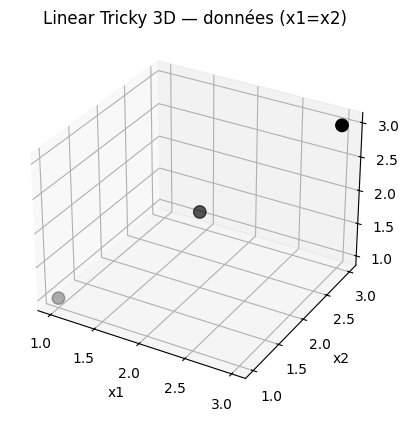

R4 — Linear Tricky 3D  (x1=x2, ridge=1e-6) :
  Pseudo-Inv : W=[0.5 0.5 0. ]  MSE=4.13e-14  (OK avec ridge)
  Grad Desc  : W=[0.5 0.5 0. ]  MSE=8.81e-11  (OK)


<Figure size 640x480 with 0 Axes>

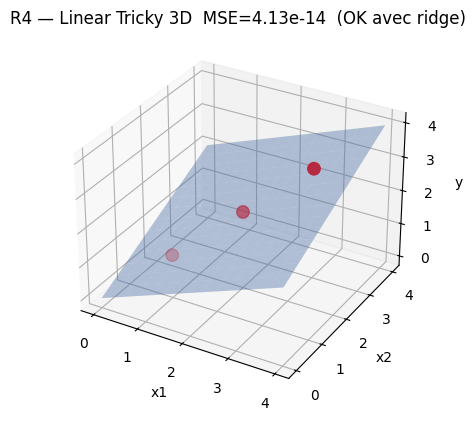

In [172]:
X_r4 = np.array([[1, 1, 1], [2, 2, 1], [3, 3, 1]], dtype=float)
Y_r4 = np.array([1.0, 2.0, 3.0])

fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_r4[:,0], X_r4[:,1], Y_r4, color='k', s=80)
ax.set_title("Linear Tricky 3D — données (x1=x2)"); ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
plt.show(); plt.clf()

W_r4_pi = call_pseudo_inverse_reg(X_r4, Y_r4, ridge=1e-6)
W_r4_gd = call_gradient_descent(X_r4, Y_r4, alpha=0.05, max_ep=5000)

print("R4 — Linear Tricky 3D  (x1=x2, ridge=1e-6) :")
print(f"  Pseudo-Inv : W={np.round(W_r4_pi,4)}  MSE={mse_py(W_r4_pi,X_r4,Y_r4):.2e}  (OK avec ridge)")
print(f"  Grad Desc  : W={np.round(W_r4_gd,4)}  MSE={mse_py(W_r4_gd,X_r4,Y_r4):.2e}  (OK)")

x1_r = np.linspace(0, 4, 15); x2_r = np.linspace(0, 4, 15)
xx1, xx2 = np.meshgrid(x1_r, x2_r)
grid = np.c_[xx1.ravel(), xx2.ravel(), np.ones(xx1.size)]
zz = (grid @ W_r4_pi).reshape(xx1.shape)

fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, zz, alpha=0.4, color='#4C72B0')
ax.scatter(X_r4[:,0], X_r4[:,1], Y_r4, color='red', s=80, zorder=5, label='Points réels')
ax.set_title(f"R4 — Linear Tricky 3D  MSE={mse_py(W_r4_pi,X_r4,Y_r4):.2e}  (OK avec ridge)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
plt.show()


### Non Linear Simple 3D :
Système inconsistant : le modèle linéaire ne peut pas trouver une solution parfaite.

        Linear Model       : KO
        MLP (2, 2, 1)      : OK


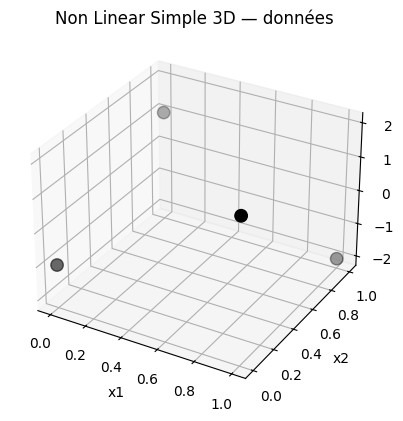

R5 — Non Linear Simple 3D :
  Pseudo-Inv : W=[ 0.  -1.   0.5]  MSE=2.2500  (KO — inconsistant)
  Grad Desc  : W=[-0.0789 -1.1579  0.5   ]  MSE=2.2718  (KO)


<Figure size 640x480 with 0 Axes>

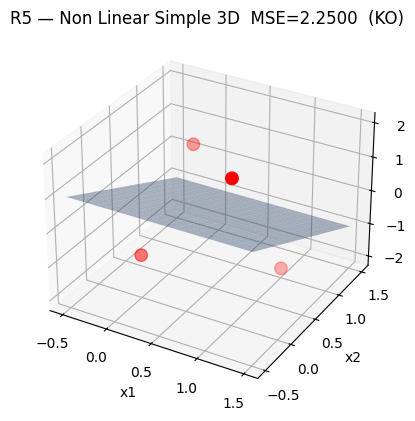

In [173]:
X_r5 = np.array([[1, 0, 1], [0, 1, 1], [1, 1, 1], [0, 0, 1]], dtype=float)
Y_r5 = np.array([2.0, 1.0, -2.0, -1.0])

fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_r5[:,0], X_r5[:,1], Y_r5, color='k', s=80)
ax.set_title("Non Linear Simple 3D — données"); ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
plt.show(); plt.clf()

W_r5_pi = call_pseudo_inverse_reg(X_r5, Y_r5)
W_r5_gd = call_gradient_descent(X_r5, Y_r5, alpha=0.05, max_ep=5000)

print("R5 — Non Linear Simple 3D :")
print(f"  Pseudo-Inv : W={np.round(W_r5_pi,4)}  MSE={mse_py(W_r5_pi,X_r5,Y_r5):.4f}  (KO — inconsistant)")
print(f"  Grad Desc  : W={np.round(W_r5_gd,4)}  MSE={mse_py(W_r5_gd,X_r5,Y_r5):.4f}  (KO)")

x1_r = np.linspace(-0.5, 1.5, 20); x2_r = np.linspace(-0.5, 1.5, 20)
xx1, xx2 = np.meshgrid(x1_r, x2_r)
grid = np.c_[xx1.ravel(), xx2.ravel(), np.ones(xx1.size)]
zz = (grid @ W_r5_pi).reshape(xx1.shape)

fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, zz, alpha=0.4, color='#4C72B0')
ax.scatter(X_r5[:,0], X_r5[:,1], Y_r5, color='red', s=80, zorder=5, label='Points réels')
ax.set_title(f"R5 — Non Linear Simple 3D  MSE={mse_py(W_r5_pi,X_r5,Y_r5):.4f}  (KO)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
plt.show()


### R6 — Dataset réel (RGB) : régression sur label continu

Labels convertis en valeur continue : `0.0 = Compost · 1.0 = Pile · 2.0 = Recyclable`  
Prédiction finale = arrondi à l'entier le plus proche.


In [174]:
Y_real_cont = Y_real.astype(np.float64)

W_r6_pi = call_pseudo_inverse_reg(X_real, Y_real_cont)
W_r6_gd = call_gradient_descent(X_real, Y_real_cont, alpha=0.01, max_ep=10000)

mse_r6_pi = mse_py(W_r6_pi, X_real, Y_real_cont)
mse_r6_gd = mse_py(W_r6_gd, X_real, Y_real_cont)

preds_r6_pi_cont = predict_reg_py(W_r6_pi, X_real)
preds_r6_gd_cont = predict_reg_py(W_r6_gd, X_real)

preds_r6_pi = np.clip(np.round(preds_r6_pi_cont).astype(int), 0, 2)
preds_r6_gd = np.clip(np.round(preds_r6_gd_cont).astype(int), 0, 2)

acc_r6_pi = np.mean(preds_r6_pi == Y_real) * 100
acc_r6_gd = np.mean(preds_r6_gd == Y_real) * 100

print("R6 — Dataset réel RGB (régression continue) :")
print(f"  n={len(Y_real)}  nf={X_real.shape[1]}  nc=3")
print()
print(f"  Pseudo-Inv : MSE={mse_r6_pi:.4f}  Accuracy (arrondie)={acc_r6_pi:.1f}%")
print(f"  Grad Desc  : MSE={mse_r6_gd:.4f}  Accuracy (arrondie)={acc_r6_gd:.1f}%")
print()
print(f"  {'Classe':12s}  | Pseudo-Inv       | Grad Desc")
print(f"  {'-'*12}--+------------------+------------------")
for cls_idx, cls_name in label_map.items():
    mask  = Y_real == cls_idx
    ok_pi = np.sum(preds_r6_pi[mask] == cls_idx)
    ok_gd = np.sum(preds_r6_gd[mask] == cls_idx)
    total = np.sum(mask)
    print(f"  {cls_name:12s}  |  {ok_pi}/{total} ({100*ok_pi/total:5.1f}%)   |  {ok_gd}/{total} ({100*ok_gd/total:5.1f}%)")


R6 — Dataset réel RGB (régression continue) :
  n=57  nf=4  nc=3

  Pseudo-Inv : MSE=0.6160  Accuracy (arrondie)=28.1%
  Grad Desc  : MSE=0.6423  Accuracy (arrondie)=31.6%

  Classe        | Pseudo-Inv       | Grad Desc
  --------------+------------------+------------------
  Compost       |  5/24 ( 20.8%)   |  4/24 ( 16.7%)
  Pile          |  7/11 ( 63.6%)   |  7/11 ( 63.6%)
  Recyclable    |  4/22 ( 18.2%)   |  7/22 ( 31.8%)


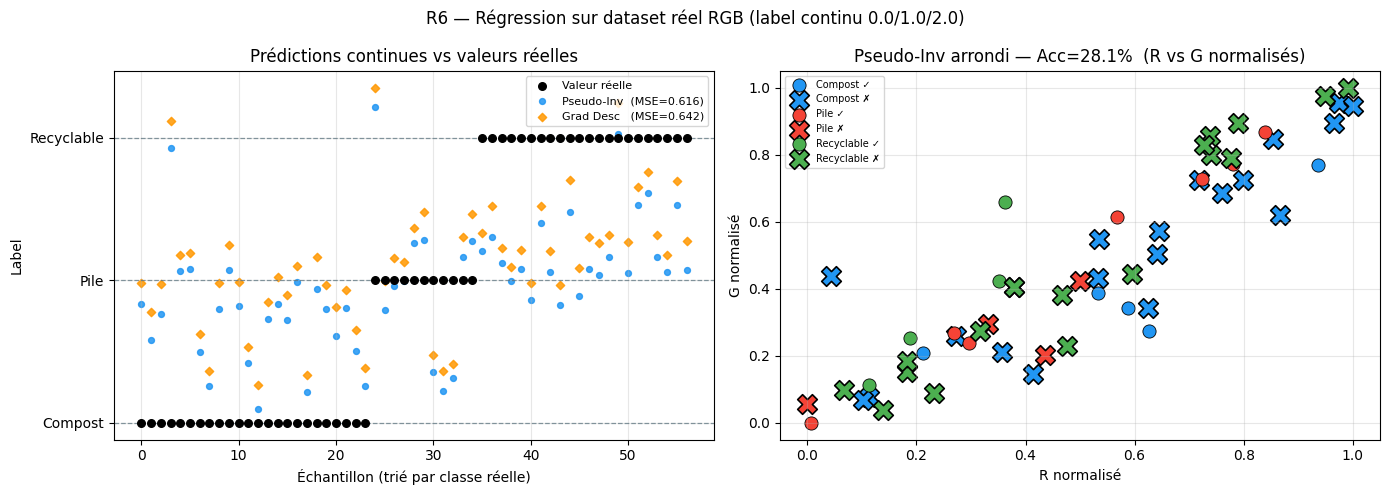

In [175]:
# Visualisation R6 : prédit vs réel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("R6 — Régression sur dataset réel RGB (label continu 0.0/1.0/2.0)", fontsize=12)

order = np.argsort(Y_real_cont)
ax = axes[0]
ax.scatter(range(len(order)), Y_real_cont[order], color='k', s=30, zorder=5, label='Valeur réelle')
ax.scatter(range(len(order)), preds_r6_pi_cont[order], color=COLORS[0], s=18, alpha=0.85,
           label=f'Pseudo-Inv  (MSE={mse_r6_pi:.3f})')
ax.scatter(range(len(order)), preds_r6_gd_cont[order], color=COLORS[3], s=18, alpha=0.85,
           marker='D', label=f'Grad Desc   (MSE={mse_r6_gd:.3f})')
for v in [0, 1, 2]:
    ax.axhline(v, color='#546E7A', ls='--', lw=0.9, alpha=0.7)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(cls_names)
ax.set_xlabel("Échantillon (trié par classe réelle)"); ax.set_ylabel("Label")
ax.set_title("Prédictions continues vs valeurs réelles")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Scatter R vs G avec ✓ / ✗ (Pseudo-Inverse arrondi)
ax = axes[1]
for c, name in label_map.items():
    mask    = Y_real == c
    correct = preds_r6_pi == c
    ax.scatter(X_real[mask & correct,  0], X_real[mask & correct,  1],
               color=COLORS[c], s=90, edgecolors='k', lw=0.6, label=f'{name} ✓')
    if np.any(mask & ~correct):
        ax.scatter(X_real[mask & ~correct, 0], X_real[mask & ~correct, 1],
                   color=COLORS[c], s=200, marker='X', edgecolors='k', lw=1.2,
                   label=f'{name} ✗')
ax.set_title(f"Pseudo-Inv arrondi — Acc={acc_r6_pi:.1f}%  (R vs G normalisés)")
ax.set_xlabel("R normalisé"); ax.set_ylabel("G normalisé")
ax.legend(fontsize=7, loc='best'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Bilan Comparatif Final — Classification

8 tests · 2 algorithmes · fonctions C appelées directement via ctypes


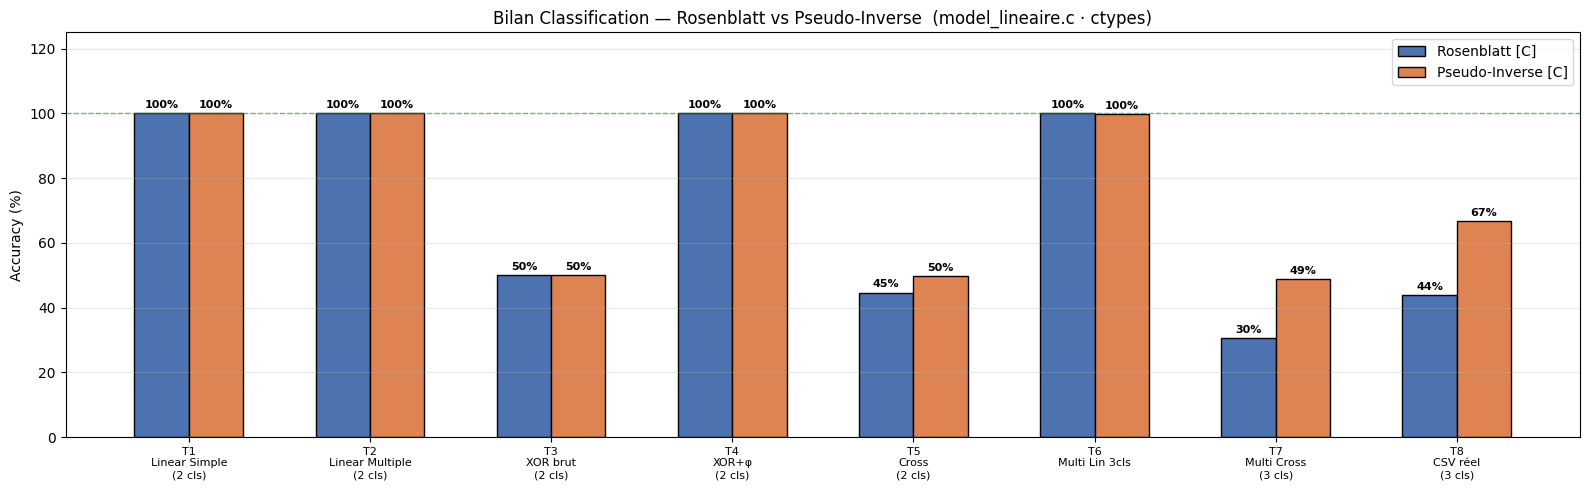


  BILAN FINAL CLASSIFICATION
  T1 (Linear Simple,   2 cls)  :  Rosenblatt 100%   | Pseudo-Inv 100%
  T2 (Linear Multiple, 2 cls)  :  Rosenblatt 100%   | Pseudo-Inv 100%
  T3 (XOR brut,        2 cls)  :  Rosenblatt 50%   | Pseudo-Inv 50%
  T4 (XOR+phi,         2 cls)  :  Rosenblatt 100%   | Pseudo-Inv 100%
  T5 (Cross,           2 cls)  :  Rosenblatt 45%   | Pseudo-Inv 50%
  T6 (Multi Lin,       3 cls)  :  Rosenblatt 100%   | Pseudo-Inv 100%
  T7 (Multi Cross,     3 cls)  :  Rosenblatt 30%   | Pseudo-Inv 49%
  T8 (CSV réel,        3 cls)  :  Rosenblatt 44%   | Pseudo-Inv 67%


In [176]:
tests_labels = [
    "T1\nLinear Simple\n(2 cls)",
    "T2\nLinear Multiple\n(2 cls)",
    "T3\nXOR brut\n(2 cls)",
    "T4\nXOR+φ\n(2 cls)",
    "T5\nCross\n(2 cls)",
    "T6\nMulti Lin 3cls",
    "T7\nMulti Cross\n(3 cls)",
    "T8\nCSV réel\n(3 cls)",
]
acc_r_all = [acc1_r, acc2_r, acc3_r, acc4_r, acc5_r, acc6_r, acc7_r, acc8_r]
acc_p_all = [acc1_p, acc2_p, acc3_p, acc4_p, acc5_p, acc6_p, acc7_p, acc8_p]

x = np.arange(len(tests_labels))
w = 0.3

fig, ax = plt.subplots(figsize=(16, 5))
br = ax.bar(x-w/2, acc_r_all, w, label='Rosenblatt [C]',     color='#4C72B0', edgecolor='k')
bp = ax.bar(x+w/2, acc_p_all, w, label='Pseudo-Inverse [C]', color='#DD8452', edgecolor='k')

for bar in list(br) + list(bp):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}%",
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tests_labels, fontsize=8)
ax.set_ylim(0, 125)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Bilan Classification — Rosenblatt vs Pseudo-Inverse  (model_lineaire.c · ctypes)", fontsize=12)
ax.legend(fontsize=10)
ax.axhline(100, color='green', ls='--', lw=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("=" * 65)
print("  BILAN FINAL CLASSIFICATION")
print("=" * 65)
labels_print = ["T1 (Linear Simple,   2 cls)", "T2 (Linear Multiple, 2 cls)",
                "T3 (XOR brut,        2 cls)", "T4 (XOR+phi,         2 cls)",
                "T5 (Cross,           2 cls)", "T6 (Multi Lin,       3 cls)",
                "T7 (Multi Cross,     3 cls)", "T8 (CSV réel,        3 cls)"]
for lbl, ar, ap in zip(labels_print, acc_r_all, acc_p_all):
    print(f"  {lbl}  :  Rosenblatt {ar:.0f}%   | Pseudo-Inv {ap:.0f}%")


## Bilan Comparatif Final — Convergence Rosenblatt

Nombre d'erreurs par époque pour chaque test de classification.


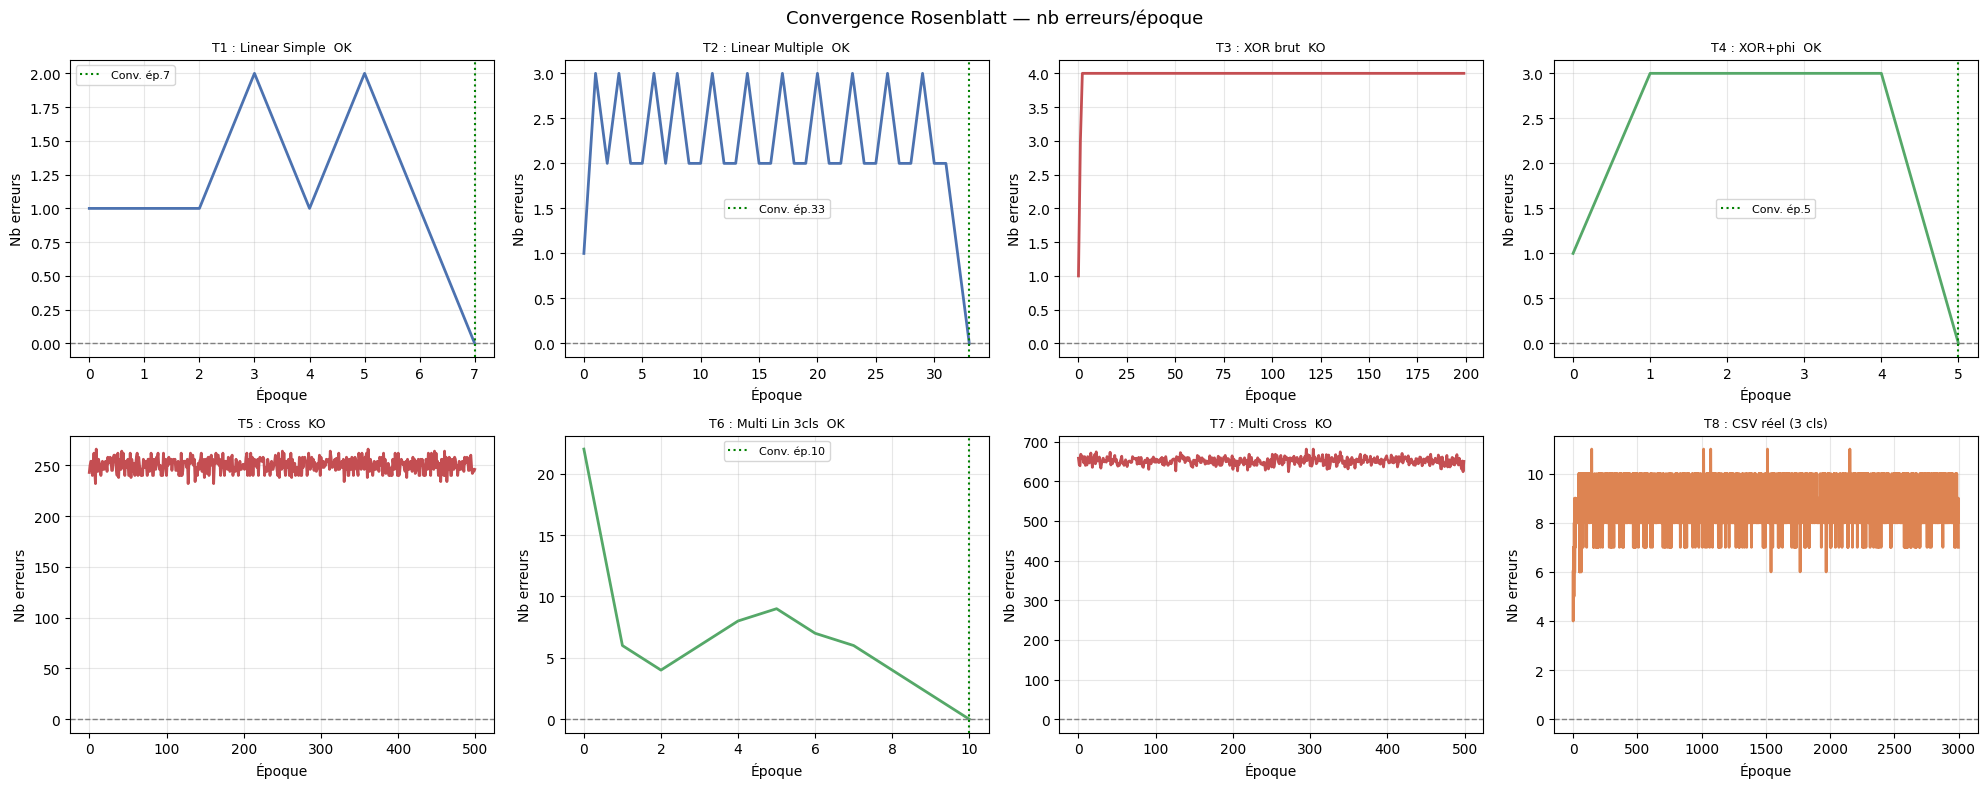

In [177]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Convergence Rosenblatt — nb erreurs/époque", fontsize=13)

conv_data = [
    (errors1_r, "T1 : Linear Simple  OK",       "#4C72B0"),
    (errors2_r, "T2 : Linear Multiple  OK",      "#4C72B0"),
    (errors3_r, "T3 : XOR brut  KO",             "#C44E52"),
    (errors4_r, "T4 : XOR+phi  OK",              "#55A868"),
    (errors5_r, "T5 : Cross  KO",                "#C44E52"),
    (errors6_r, "T6 : Multi Lin 3cls  OK",       "#55A868"),
    (errors7_r, "T7 : Multi Cross  KO",          "#C44E52"),
    (errors8_r, "T8 : CSV réel (3 cls)",         "#DD8452"),
]

for ax, (errs, title, col) in zip(axes.ravel(), conv_data):
    ax.plot(errs, color=col, lw=2)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Époque"); ax.set_ylabel("Nb erreurs")
    ax.grid(True, alpha=0.3)
    if min(errs) == 0:
        ep = errs.index(0)
        ax.axvline(ep, color='green', ls=':', lw=1.5, label=f"Conv. ép.{ep}")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Bilan Comparatif Final — Régression

6 tests · 2 algorithmes · fonctions C appelées directement via ctypes


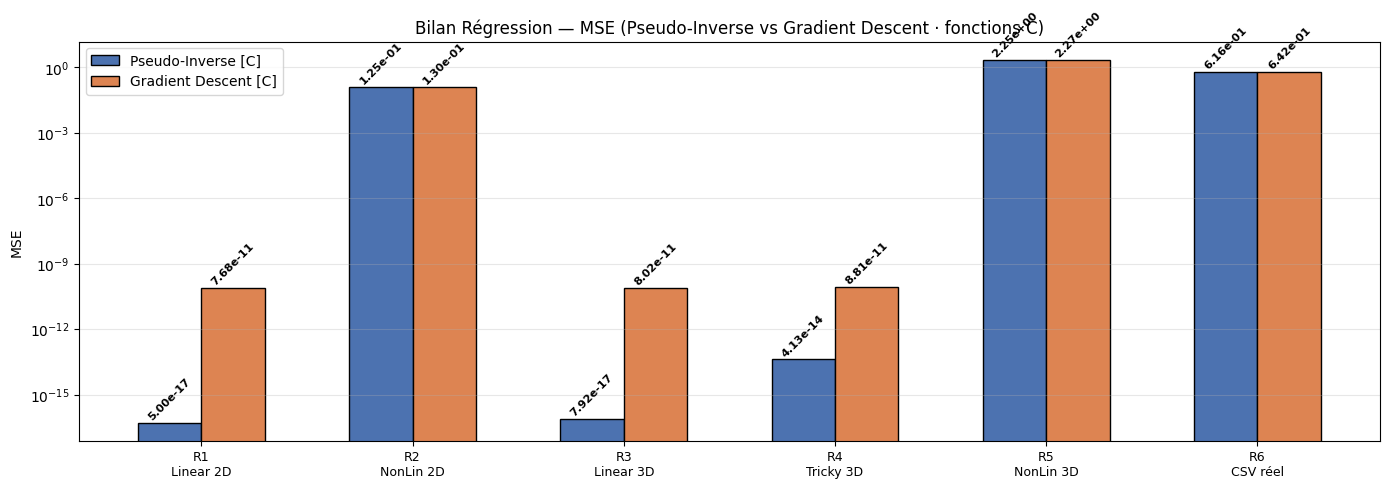


  BILAN REGRESSION  (fonctions C appelées via ctypes)
  R1 (Linear 2D)   :  PI MSE=5.00e-17  |  GD MSE=7.68e-11  -> OK
  R2 (NonLin 2D)   :  PI MSE=1.25e-01  |  GD MSE=1.30e-01  -> OK (meilleure droite)
  R3 (Linear 3D)   :  PI MSE=7.92e-17  |  GD MSE=8.02e-11  -> OK
  R4 (Tricky 3D)   :  PI MSE=4.13e-14  |  GD MSE=8.81e-11  -> OK (ridge)
  R5 (NonLin 3D)   :  PI MSE=2.25e+00  |  GD MSE=2.27e+00  -> KO (non linéaire)
  R6 (CSV réel)    :  PI MSE=6.16e-01  |  GD MSE=6.42e-01  -> Acc=28% (label continu arrondi)


In [178]:
mse_r_pi = [
    mse_py(W_r1_pi, X_r1, Y_r1),
    mse_py(W_r2_pi, X_r2, Y_r2),
    mse_py(W_r3_pi, X_r3, Y_r3),
    mse_py(W_r4_pi, X_r4, Y_r4),
    mse_py(W_r5_pi, X_r5, Y_r5),
    mse_r6_pi,
]
mse_r_gd = [
    mse_py(W_r1_gd, X_r1, Y_r1),
    mse_py(W_r2_gd, X_r2, Y_r2),
    mse_py(W_r3_gd, X_r3, Y_r3),
    mse_py(W_r4_gd, X_r4, Y_r4),
    mse_py(W_r5_gd, X_r5, Y_r5),
    mse_r6_gd,
]
reg_labels = ["R1\nLinear 2D", "R2\nNonLin 2D", "R3\nLinear 3D",
              "R4\nTricky 3D", "R5\nNonLin 3D", "R6\nCSV réel"]
x = np.arange(len(reg_labels))
w = 0.3

fig, ax = plt.subplots(figsize=(14, 5))
br = ax.bar(x-w/2, mse_r_pi, w, label='Pseudo-Inverse [C]',   color='#4C72B0', edgecolor='k')
bp = ax.bar(x+w/2, mse_r_gd, w, label='Gradient Descent [C]', color='#DD8452', edgecolor='k')

for bar in list(br) + list(bp):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h*1.1, f"{h:.2e}",
            ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(reg_labels, fontsize=9)
ax.set_ylabel("MSE"); ax.set_yscale('log')
ax.set_title("Bilan Régression — MSE (Pseudo-Inverse vs Gradient Descent · fonctions C)", fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("=" * 75)
print("  BILAN REGRESSION  (fonctions C appelées via ctypes)")
print("=" * 75)
ok_list = ["OK", "OK (meilleure droite)", "OK", "OK (ridge)", "KO (non linéaire)",
           f"Acc={acc_r6_pi:.0f}% (label continu arrondi)"]
lbls = ["R1 (Linear 2D)   ", "R2 (NonLin 2D)   ", "R3 (Linear 3D)   ",
        "R4 (Tricky 3D)   ", "R5 (NonLin 3D)   ", "R6 (CSV réel)    "]
for lbl, o, mpi, mgd in zip(lbls, ok_list, mse_r_pi, mse_r_gd):
    print(f"  {lbl}:  PI MSE={mpi:.2e}  |  GD MSE={mgd:.2e}  -> {o}")
